<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('breast-cancer-wisconsin-data_data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
df.duplicated().sum()

np.int64(0)

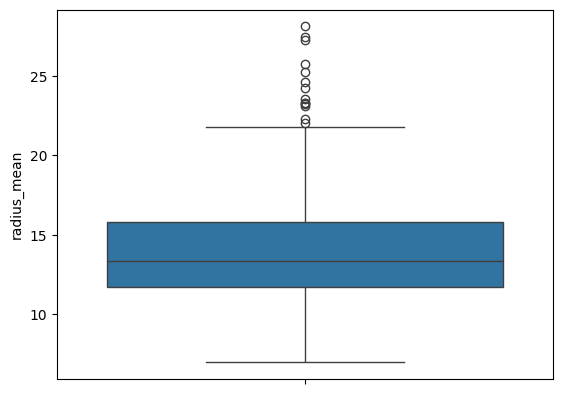

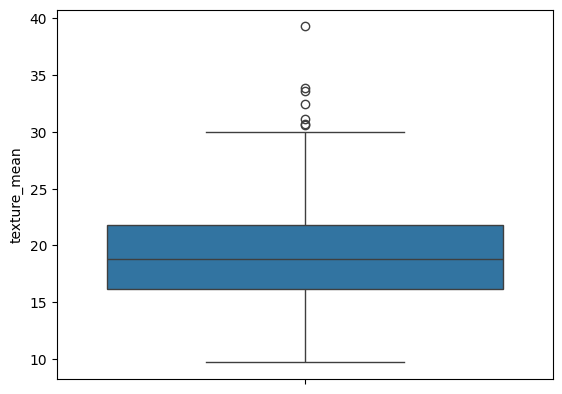

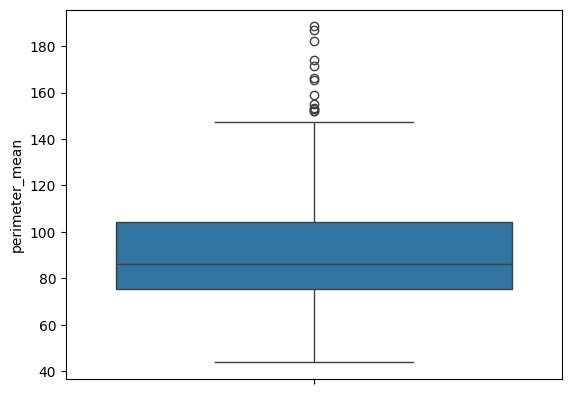

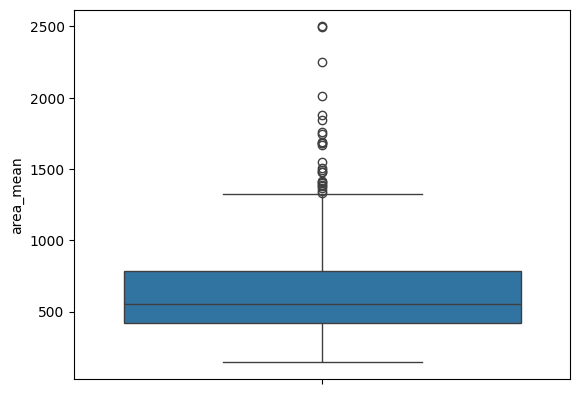

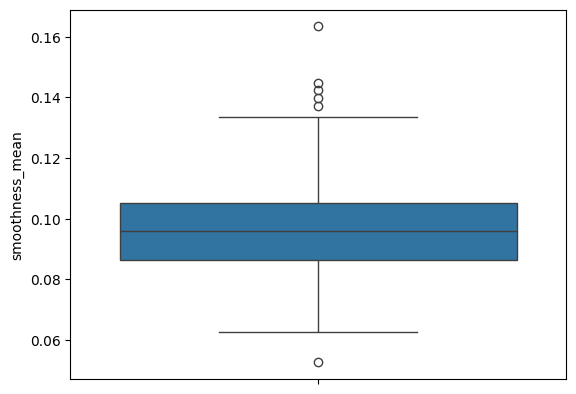

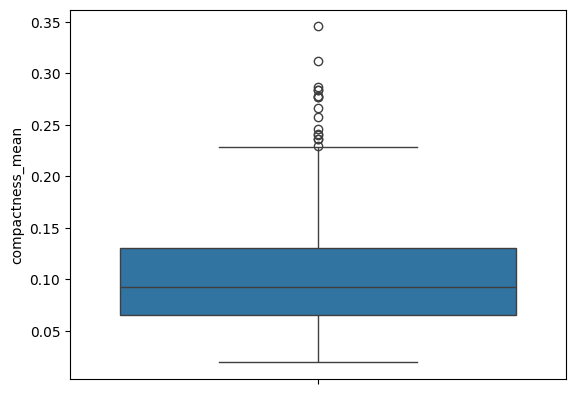

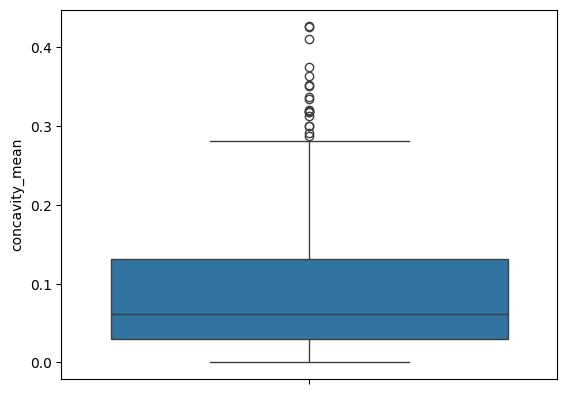

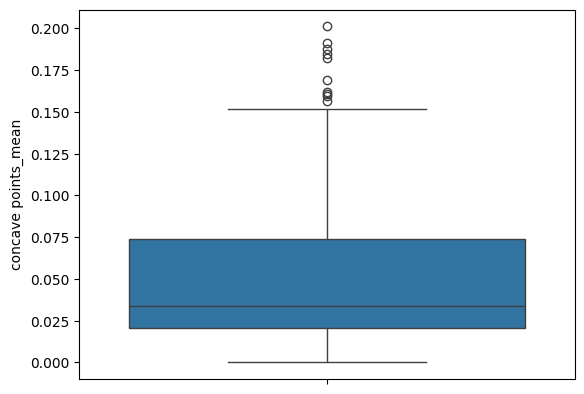

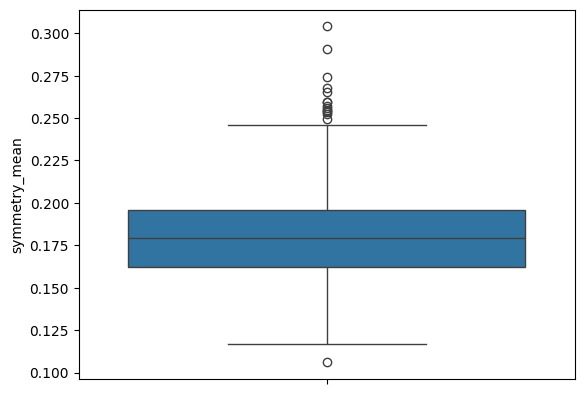

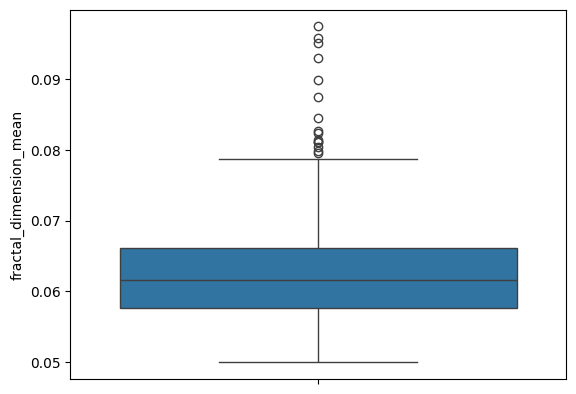

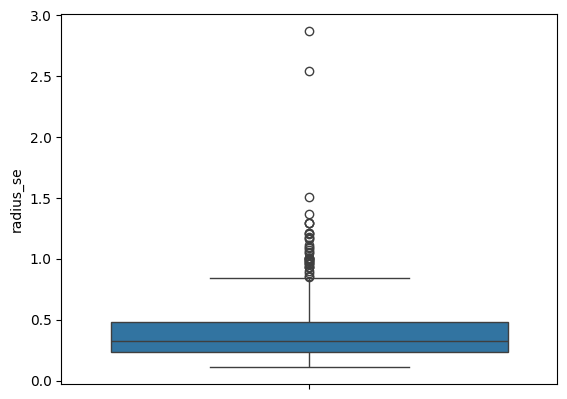

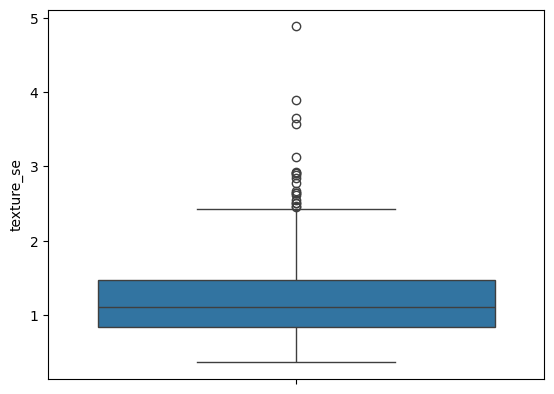

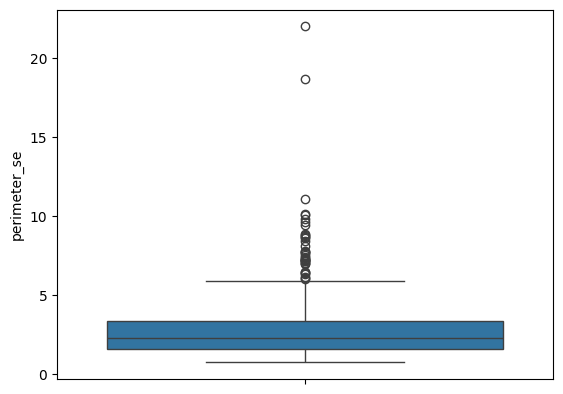

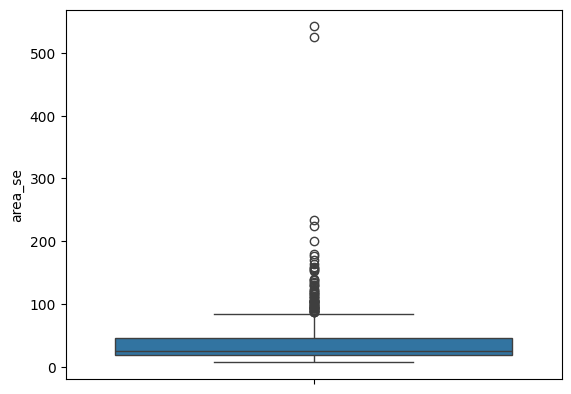

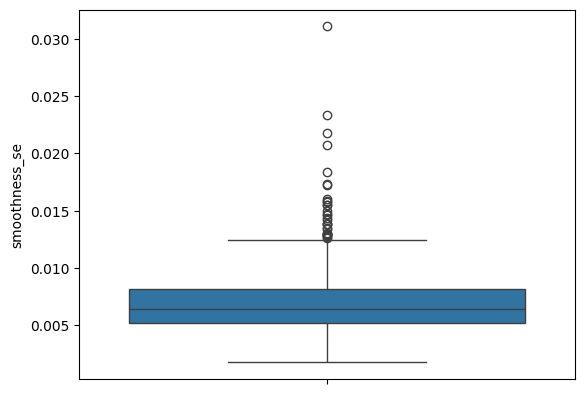

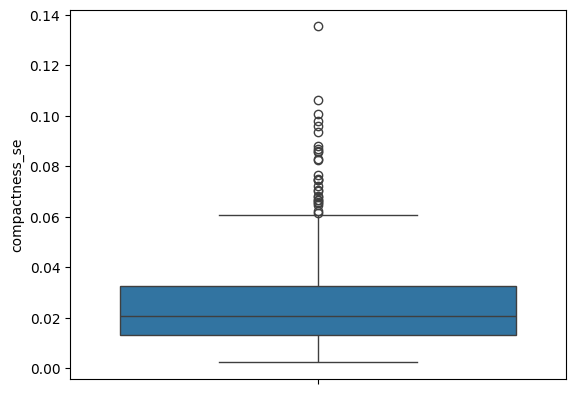

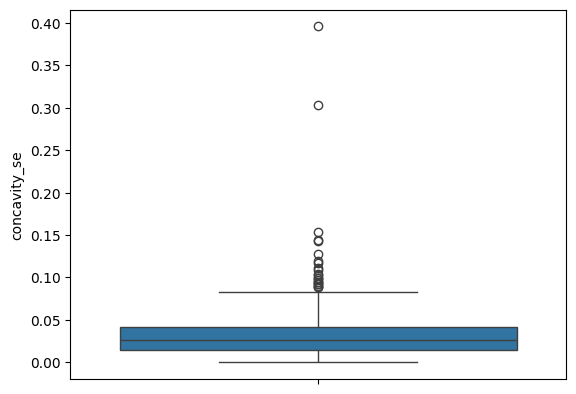

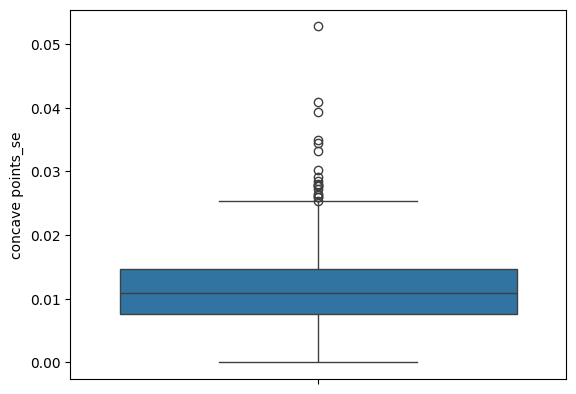

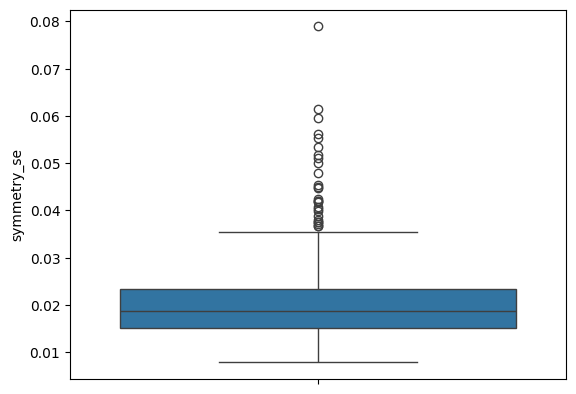

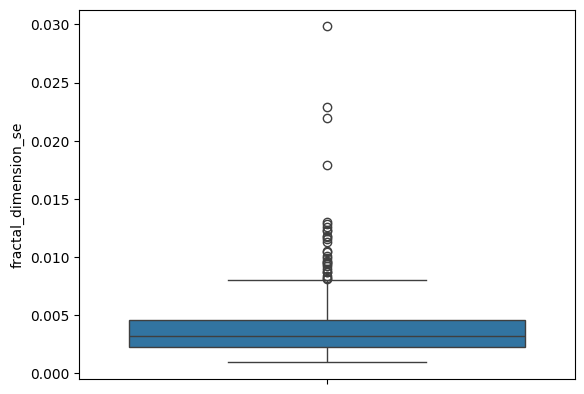

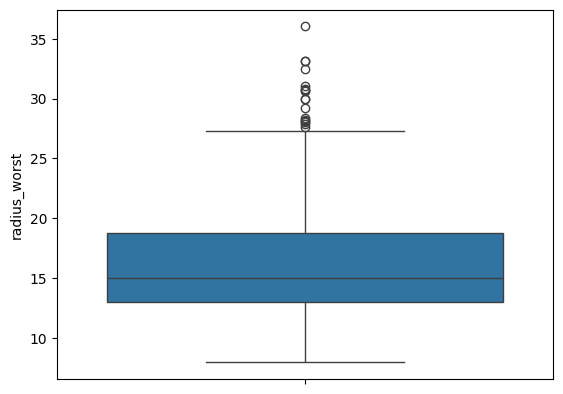

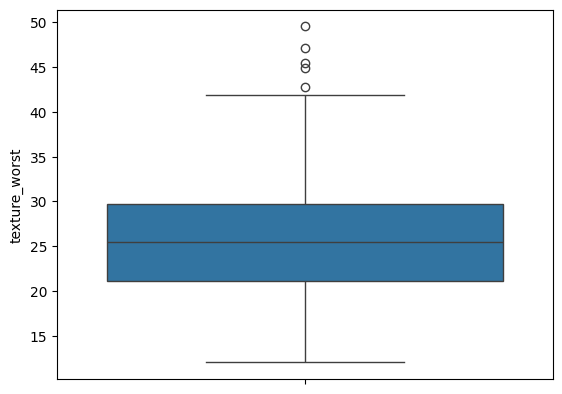

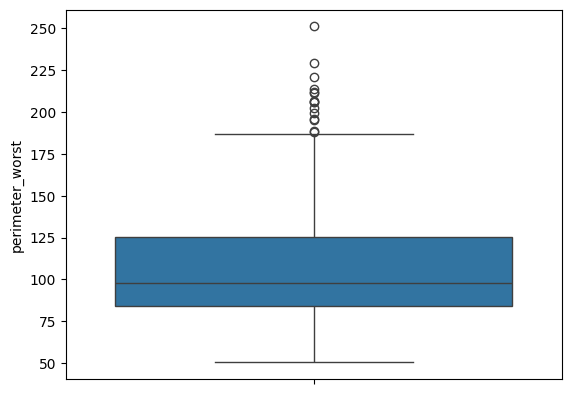

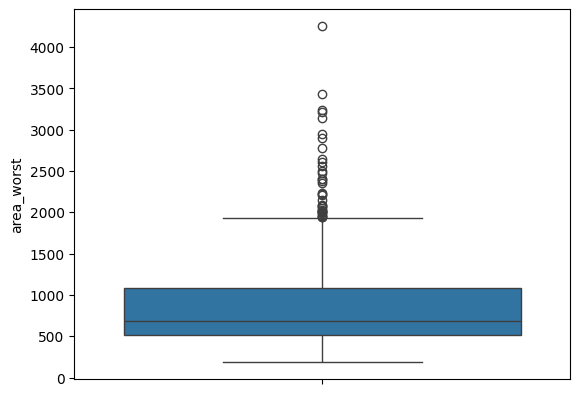

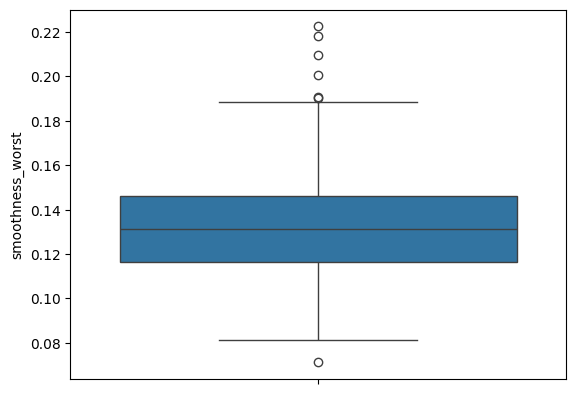

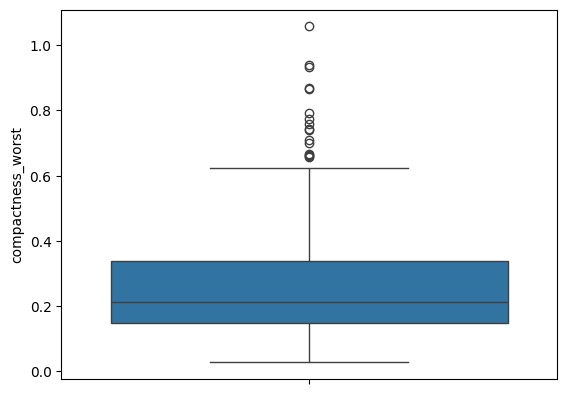

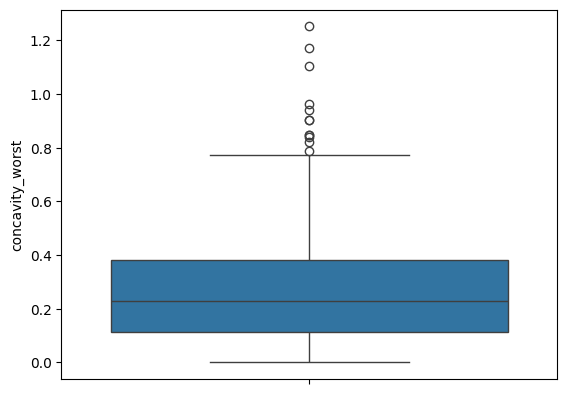

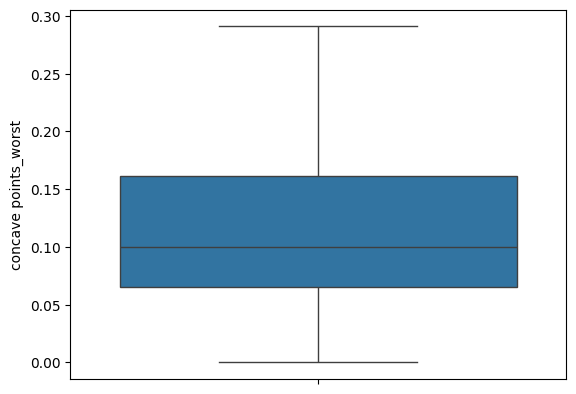

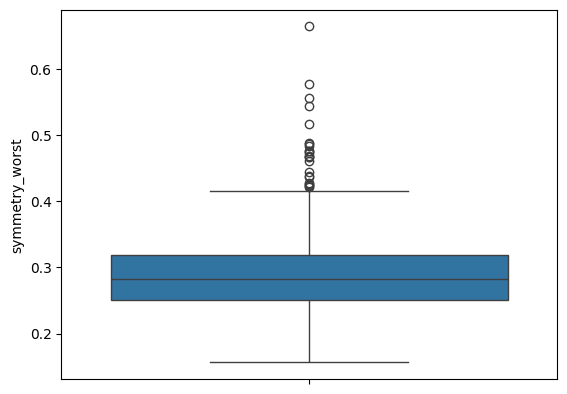

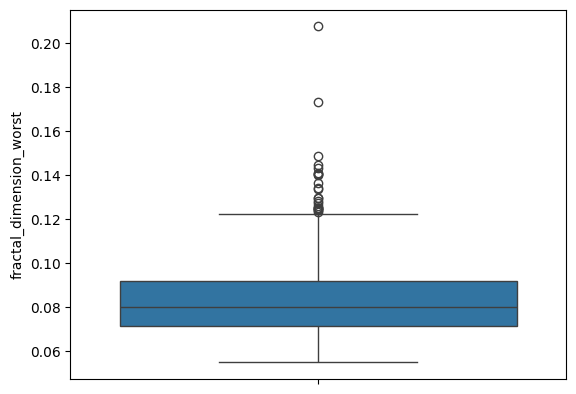

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)

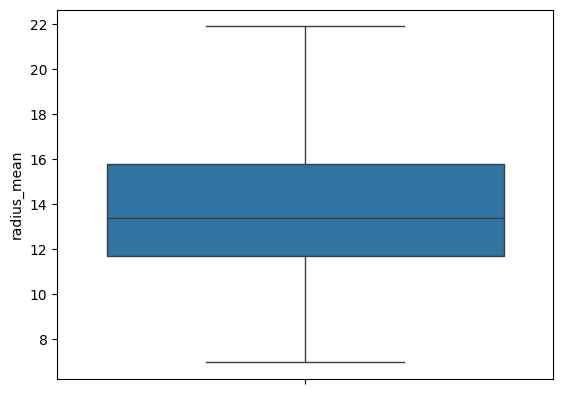

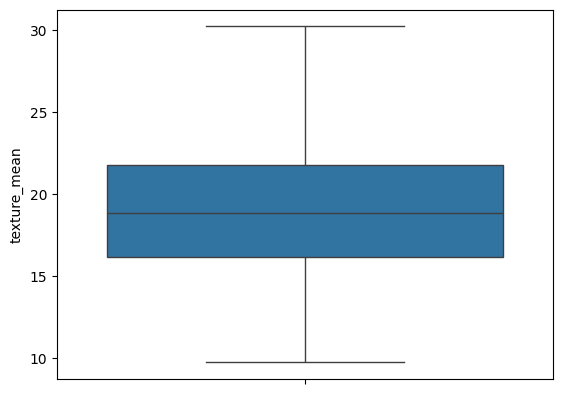

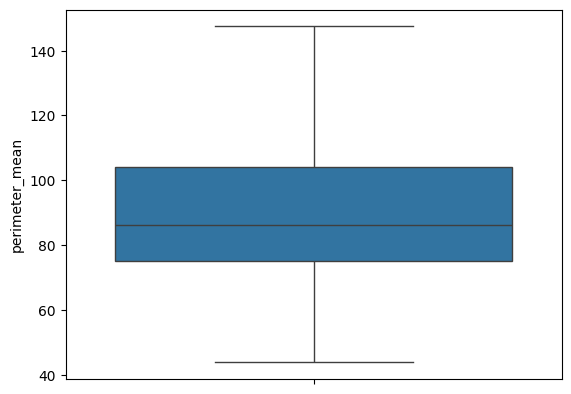

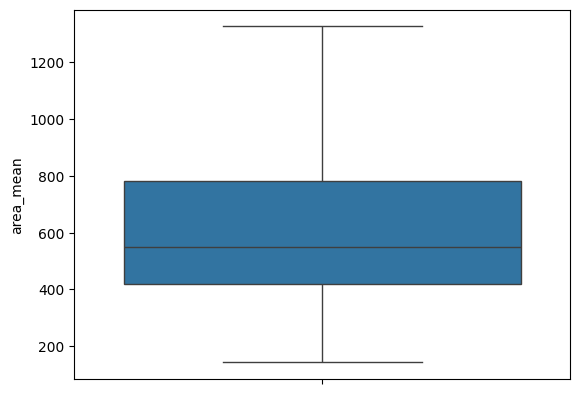

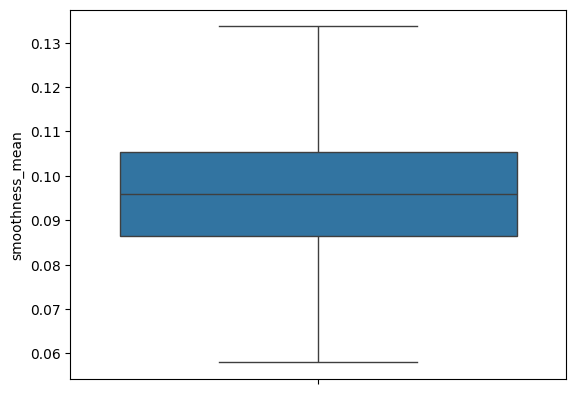

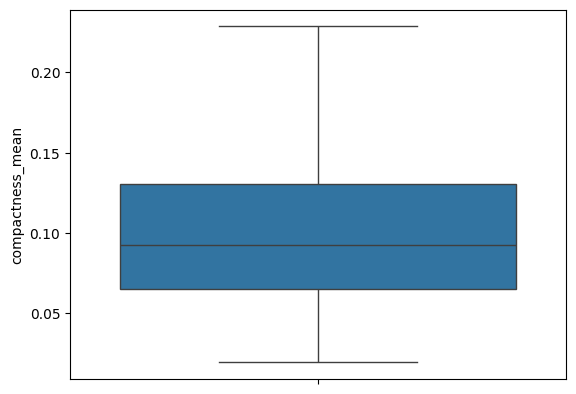

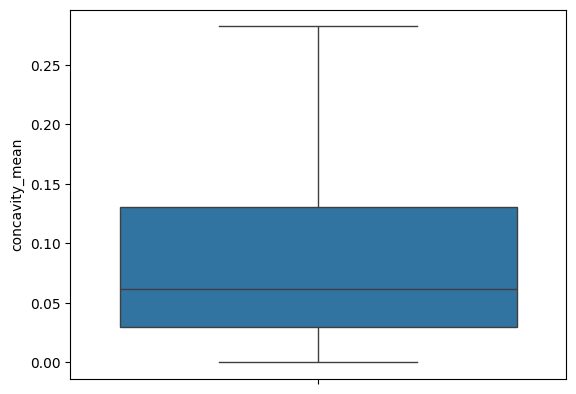

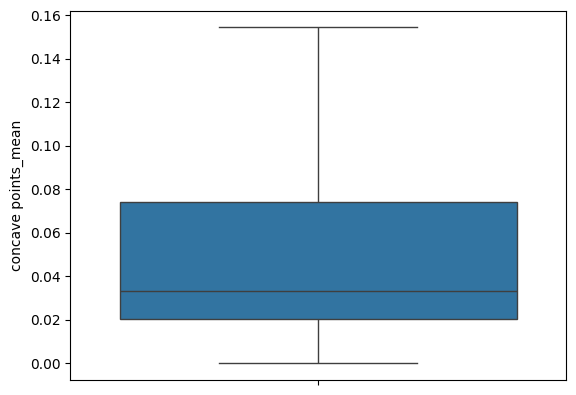

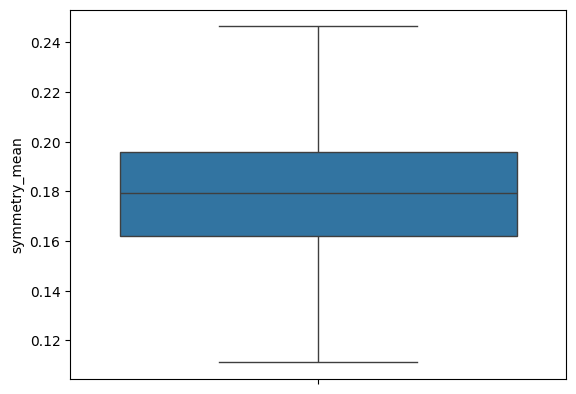

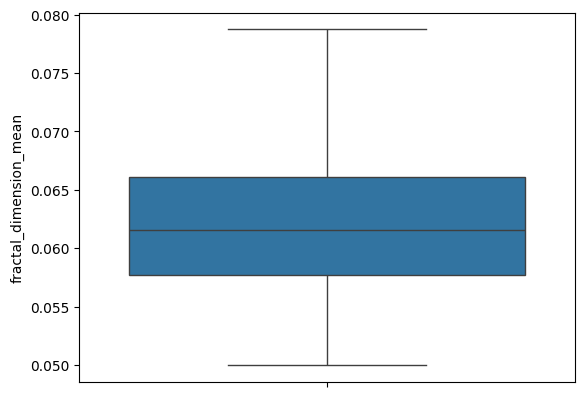

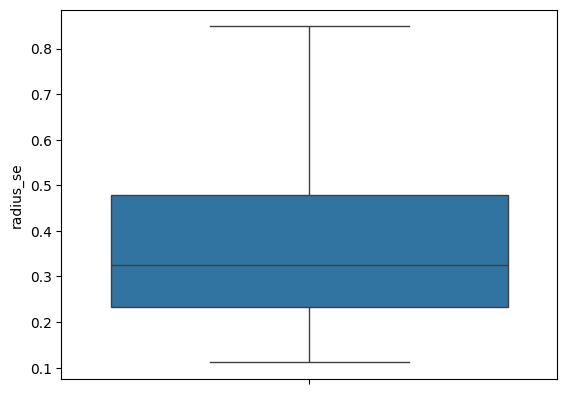

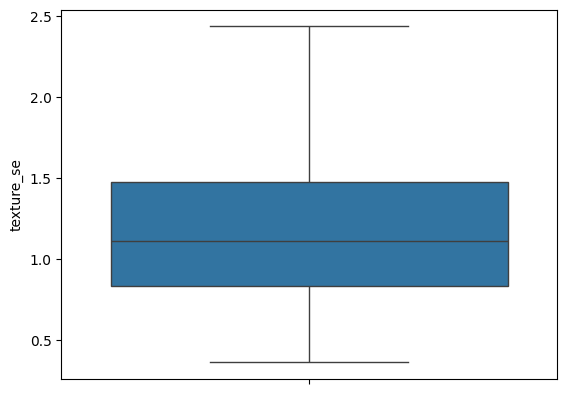

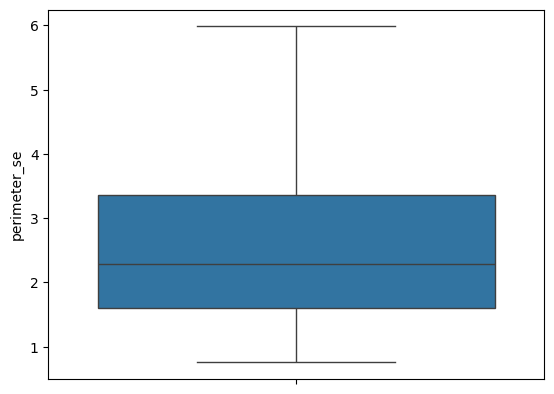

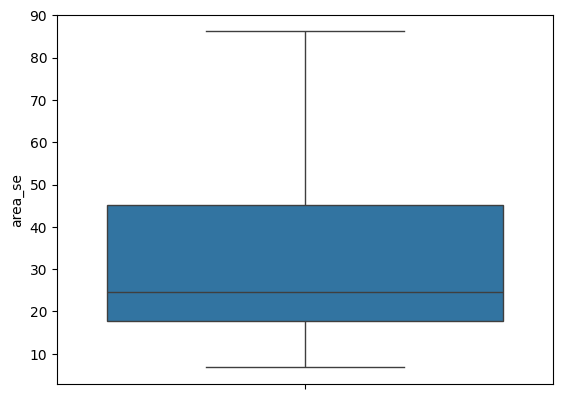

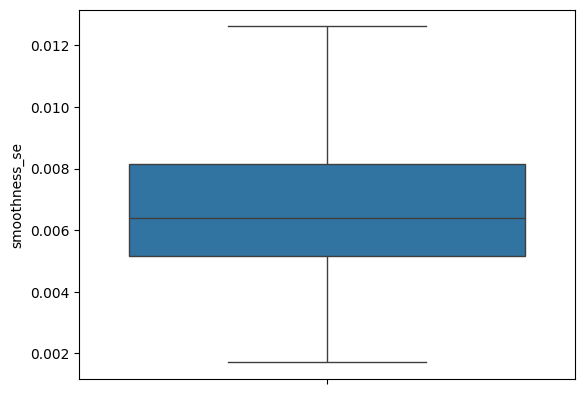

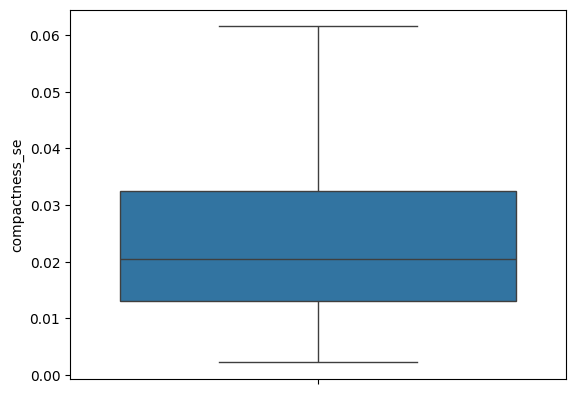

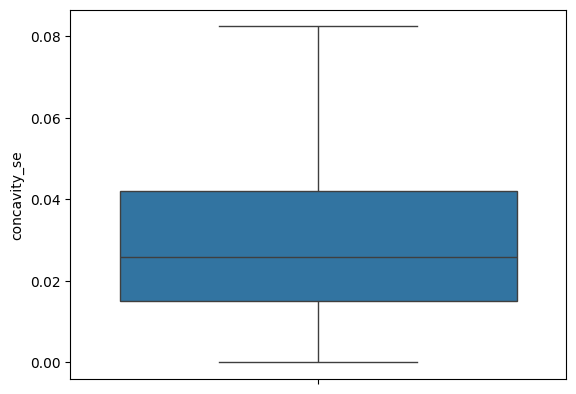

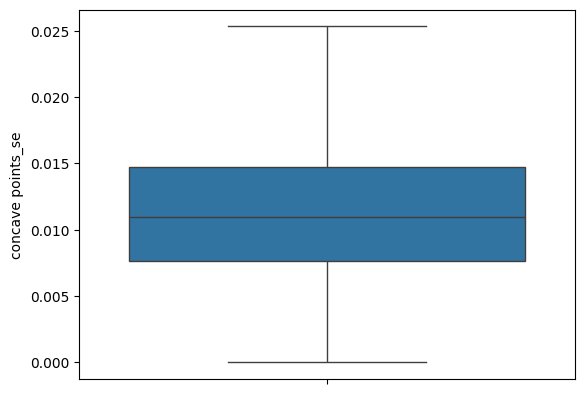

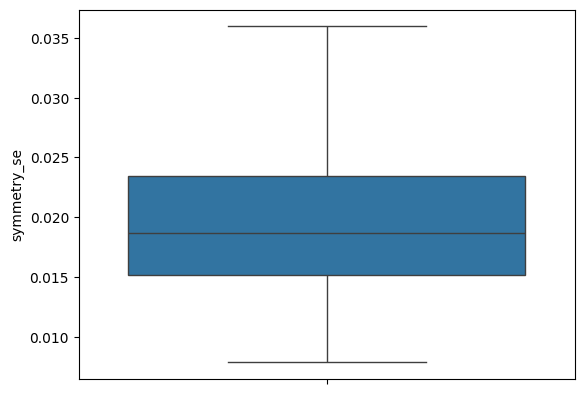

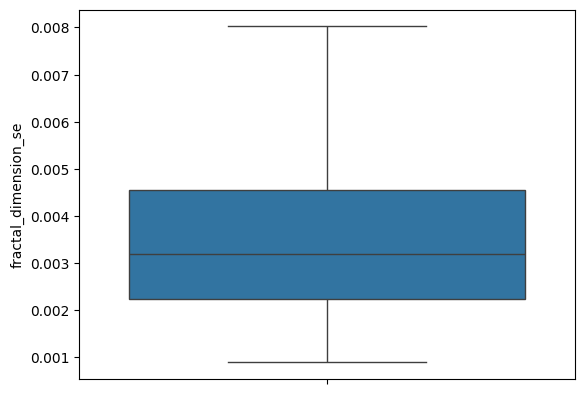

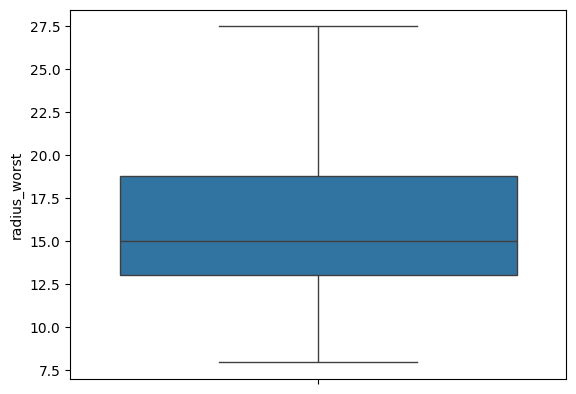

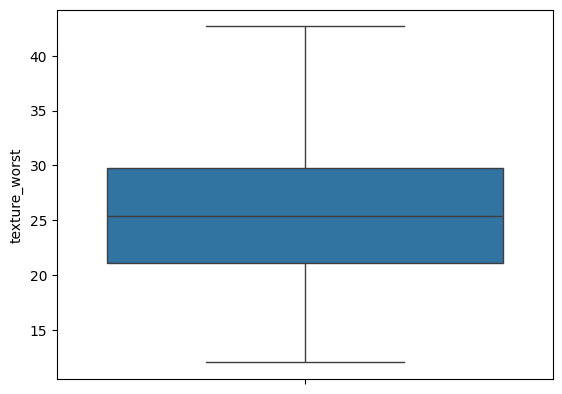

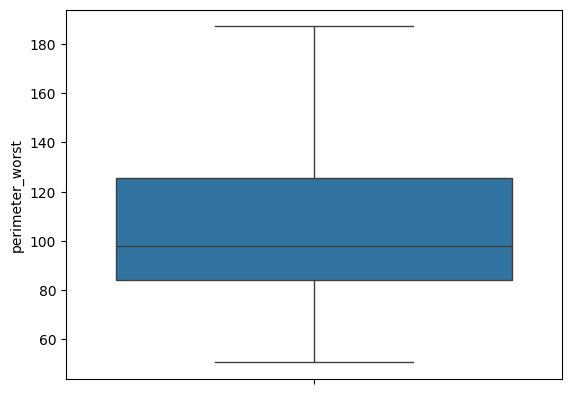

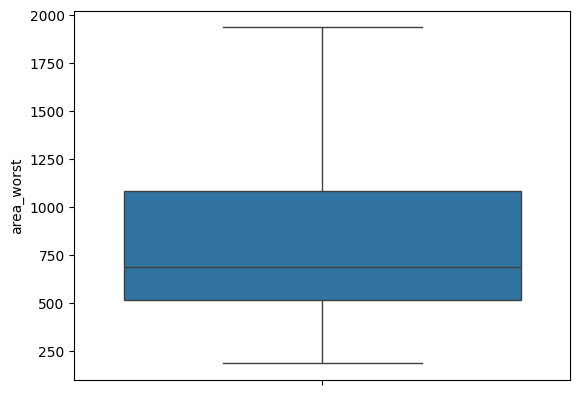

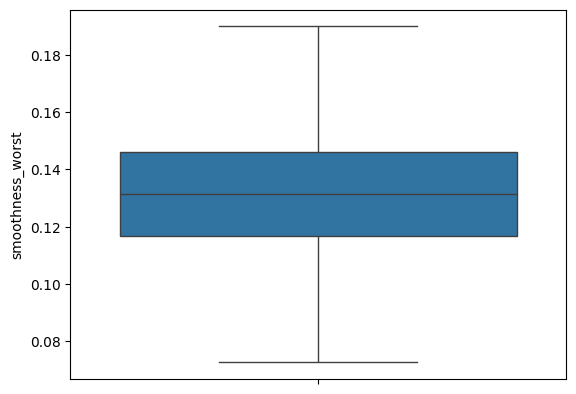

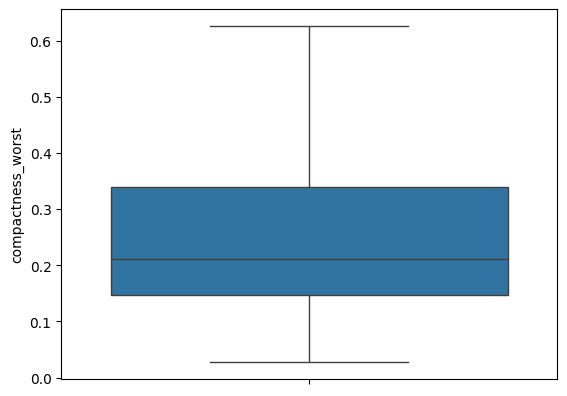

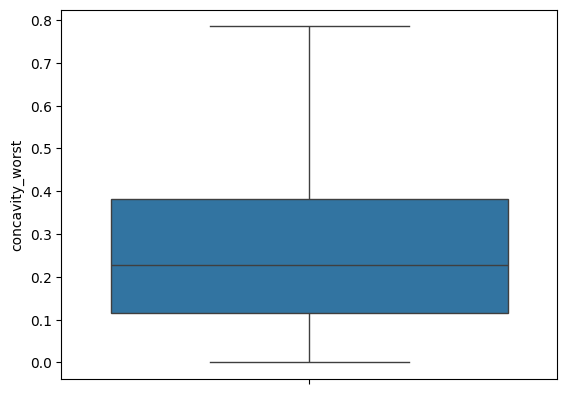

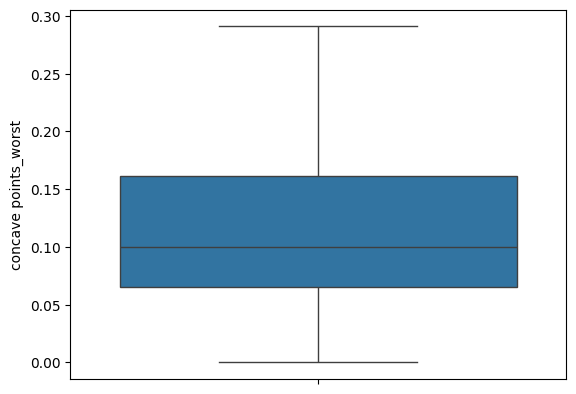

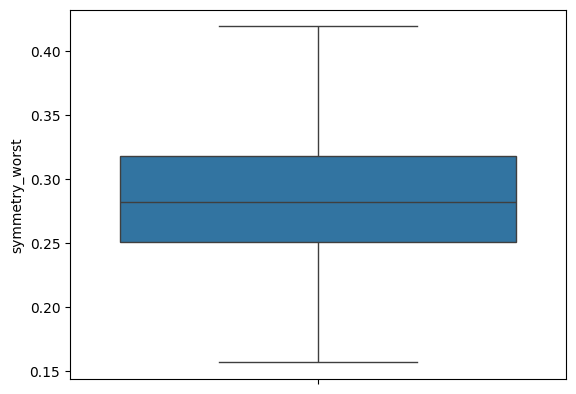

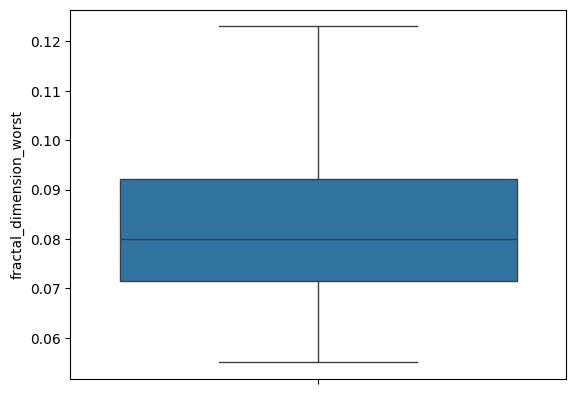

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,...,25.380,17.33,184.60,1937.05,0.16220,0.62695,0.7119,0.2654,0.41915,0.11890
1,M,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1937.05,0.12380,0.18660,0.2416,0.1860,0.27500,0.08902
2,M,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.00,0.14440,0.42450,0.4504,0.2430,0.36130,0.08758
3,M,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,...,14.910,26.50,98.87,567.70,0.19010,0.62695,0.6869,0.2575,0.41915,0.12301
4,M,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.00,0.13740,0.20500,0.4000,0.1625,0.23640,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1326.3,0.111000,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,1937.05,0.14100,0.21130,0.4107,0.2216,0.20600,0.07115
565,M,20.13,28.25,131.20,1261.0,0.097800,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.00,0.11660,0.19220,0.3215,0.1628,0.25720,0.06637
566,M,16.60,28.08,108.30,858.1,0.084550,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.00,0.11390,0.30940,0.3403,0.1418,0.22180,0.07820
567,M,20.60,29.33,140.10,1265.0,0.117800,0.22862,0.28241,0.15200,0.2397,...,25.740,39.42,184.60,1821.00,0.16500,0.62695,0.7855,0.2650,0.40870,0.12301


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,...,25.380,17.33,184.60,1937.05,0.16220,0.62695,0.7119,0.2654,0.41915,0.11890
1,1,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1937.05,0.12380,0.18660,0.2416,0.1860,0.27500,0.08902
2,1,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.00,0.14440,0.42450,0.4504,0.2430,0.36130,0.08758
3,1,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,...,14.910,26.50,98.87,567.70,0.19010,0.62695,0.6869,0.2575,0.41915,0.12301
4,1,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.00,0.13740,0.20500,0.4000,0.1625,0.23640,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1326.3,0.111000,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,1937.05,0.14100,0.21130,0.4107,0.2216,0.20600,0.07115
565,1,20.13,28.25,131.20,1261.0,0.097800,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.00,0.11660,0.19220,0.3215,0.1628,0.25720,0.06637
566,1,16.60,28.08,108.30,858.1,0.084550,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.00,0.11390,0.30940,0.3403,0.1418,0.22180,0.07820
567,1,20.60,29.33,140.10,1265.0,0.117800,0.22862,0.28241,0.15200,0.2397,...,25.740,39.42,184.60,1821.00,0.16500,0.62695,0.7855,0.2650,0.40870,0.12301


<Axes: >

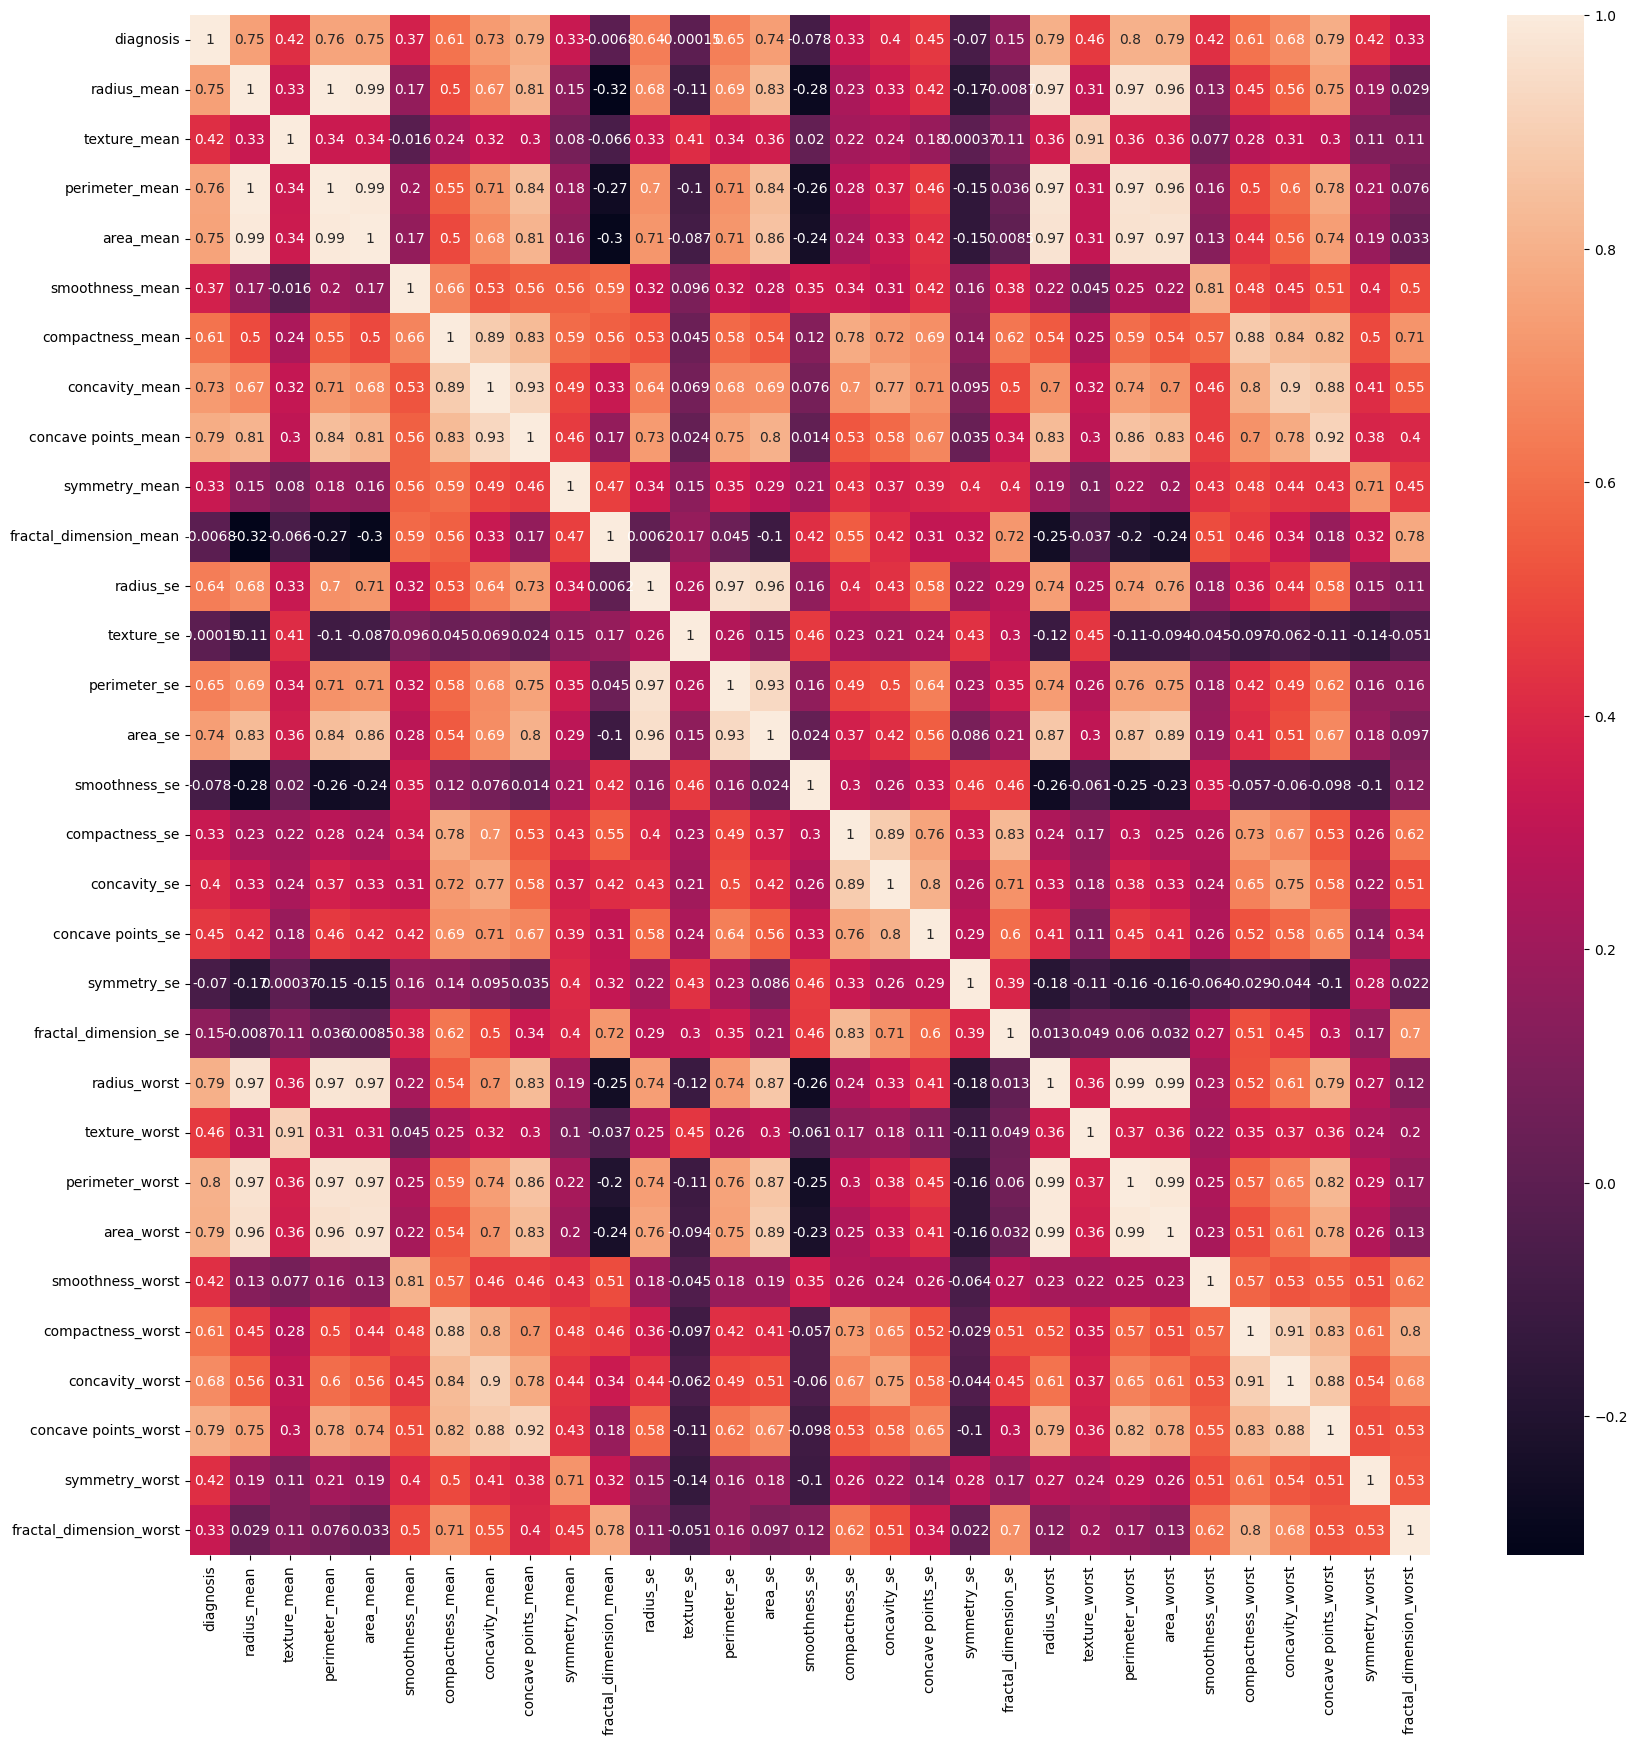

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
# f-classification
feat=df.drop(columns=['diagnosis'])
tar=df['diagnosis']

In [ ]:
from sklearn.feature_selection import f_classif
pd.Series(f_classif(feat,tar)[0],index=feat.columns).sort_values(ascending=False)

,0
perimeter_worst,1012.338365
area_worst,971.473689
radius_worst,966.829905
concave points_worst,964.385393
concave points_mean,929.435001
perimeter_mean,770.546993
area_mean,741.521069
radius_mean,708.155869
area_se,682.507418
concavity_mean,636.243499


<Axes: >

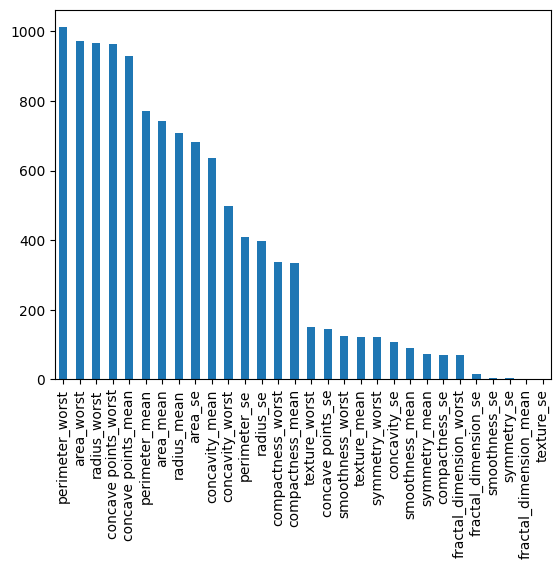

In [ ]:
pd.Series(f_classif(feat,tar)[0],index=feat.columns).sort_values(ascending=False).plot(kind='bar')

In [ ]:
scores=pd.DataFrame(f_classif(feat,tar)[0],index=feat.columns,columns=['F_score'])
scores.sort_values(by='F_score',ascending=False).head(10).index

Index(['perimeter_worst', 'area_worst', 'radius_worst', 'concave points_worst',
       'concave points_mean', 'perimeter_mean', 'area_mean', 'radius_mean',
       'area_se', 'concavity_mean'],
      dtype='object')

In [ ]:
x=df[['perimeter_worst', 'area_worst', 'radius_worst', 'concave points_worst',
       'concave points_mean', 'perimeter_mean', 'area_mean', 'radius_mean',
       'area_se', 'concavity_mean']]
y=df['diagnosis']

In [ ]:
x

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,area_mean,radius_mean,area_se,concavity_mean
0,184.60,1937.05,25.380,0.2654,0.14710,122.80,1001.0,17.99,86.20,0.28241
1,158.80,1937.05,24.990,0.1860,0.07017,132.90,1326.0,20.57,74.08,0.08690
2,152.50,1709.00,23.570,0.2430,0.12790,130.00,1203.0,19.69,86.20,0.19740
3,98.87,567.70,14.910,0.2575,0.10520,77.58,386.1,11.42,27.23,0.24140
4,152.20,1575.00,22.540,0.1625,0.10430,135.10,1297.0,20.29,86.20,0.19800
...,...,...,...,...,...,...,...,...,...,...
564,166.10,1937.05,25.450,0.2216,0.13890,142.00,1326.3,21.56,86.20,0.24390
565,155.00,1731.00,23.690,0.1628,0.09791,131.20,1261.0,20.13,86.20,0.14400
566,126.70,1124.00,18.980,0.1418,0.05302,108.30,858.1,16.60,48.55,0.09251
567,184.60,1821.00,25.740,0.2650,0.15200,140.10,1265.0,20.60,86.20,0.28241


In [ ]:
y

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
pred=lr.predict(x_train)
pred
from sklearn.metrics import *
print(accuracy_score(y_train,pred))
print(classification_report(y_train,pred))

0.9428571428571428
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       282
           1       0.94      0.91      0.92       173

    accuracy                           0.94       455
   macro avg       0.94      0.94      0.94       455
weighted avg       0.94      0.94      0.94       455



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

sc = StandardScaler()

# Fit scaler only on training data, then transform
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

pred = lr.predict(x_test_scaled)

print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        75
           1       0.97      0.95      0.96        39

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
lr.predict(x_test_scaled)

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [ ]:
x_test

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,area_mean,radius_mean,area_se,concavity_mean
356,94.22,591.20,14.19,0.12580,0.05603,85.09,512.0,13.05,21.57,0.096030
556,67.88,347.30,10.65,0.02232,0.01116,64.73,311.7,10.16,16.80,0.005025
283,126.90,1031.00,18.55,0.17320,0.09052,108.80,805.1,16.24,28.09,0.194800
495,103.90,783.60,16.01,0.10170,0.04951,96.12,680.9,14.87,21.84,0.068240
364,93.76,663.50,14.73,0.06987,0.01473,85.48,552.4,13.40,13.22,0.021810
...,...,...,...,...,...,...,...,...,...,...
138,121.40,971.40,18.55,0.16670,0.08624,96.85,678.1,14.95,86.20,0.153900
208,99.48,639.30,14.55,0.11260,0.05102,87.02,529.4,13.11,15.09,0.087050
24,177.00,1937.05,26.46,0.20950,0.09170,110.00,904.6,16.65,86.20,0.152500
264,140.50,1436.00,21.58,0.19840,0.06527,111.60,928.3,17.19,45.42,0.090610


In [ ]:
len(lr.predict_proba(x_test_scaled)[:,1])

114

In [ ]:
lr.predict_proba(x_test_scaled)[:,1]

array([1.10900611e-01, 2.03720911e-04, 9.77987689e-01, 1.28004111e-01,
       1.09937742e-02, 3.42357513e-03, 2.65353688e-03, 5.33796946e-02,
       5.29226566e-02, 2.18355804e-03, 1.91392572e-03, 2.27126815e-03,
       6.49345123e-04, 4.66157255e-01, 4.84027236e-02, 3.57776951e-01,
       9.57054994e-03, 9.99771335e-01, 9.99999193e-01, 9.99867563e-01,
       9.73935931e-03, 2.33005467e-03, 5.43519288e-04, 3.36373050e-02,
       3.38691772e-02, 2.72586546e-02, 9.98382548e-01, 4.84933225e-03,
       8.38925901e-04, 9.95623465e-01, 1.48389252e-02, 2.33941746e-01,
       9.99996707e-01, 4.83304169e-01, 1.20547507e-01, 2.10608911e-03,
       1.43027869e-02, 5.42083068e-03, 7.82858484e-05, 9.70623397e-03,
       5.80926429e-03, 9.98124949e-01, 9.99999604e-01, 6.19337179e-03,
       8.13775565e-04, 4.00908159e-04, 2.81474248e-01, 9.16726335e-01,
       1.54006642e-01, 9.95239486e-01, 1.31519702e-03, 9.81914863e-01,
       4.79540121e-01, 1.62900873e-02, 1.17902794e-02, 9.63689851e-01,
      

In [ ]:
lr.predict_proba(x_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
sigmoid=lr.predict_proba(x_test_scaled)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve
auc_score=roc_auc_score(y_test,sigmoid)
auc_score

np.float64(0.9890598290598291)

In [ ]:
roc_curve(y_test,sigmoid)
#1st array..FPR
#2nd array..TPR
#3RD array..sigmoid

(array([0.        , 0.        , 0.        , 0.01333333, 0.01333333,
        0.4       , 0.4       , 1.        ]),
 array([0.        , 0.02564103, 0.92307692, 0.92307692, 0.97435897,
        0.97435897, 1.        , 1.        ]),
 array([           inf, 9.99999727e-01, 7.87666853e-01, 7.59600425e-01,
        4.83304169e-01, 2.48813100e-02, 1.71705812e-02, 7.82858484e-05]))

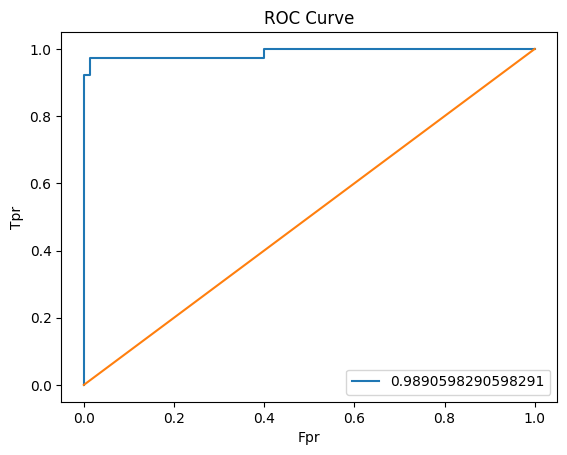

In [ ]:
fpr,tpr,thr=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,label=f'{auc_score}')
plt.plot([0,1])
plt.xlabel('Fpr')
plt.ylabel('Tpr')
plt.title('ROC Curve')
plt.legend()
plt.show()